# Did the average Filipino's life actually get better between 1960 and 2025?

Five charts, in order: what grew, how unevenly it grew, how long people
lived, how much the economy relied on money from abroad, and who ended up
holding it.

Source: World Bank API, 12 indicators, 1960-2025. Built from
`data/processed/indicators.csv`. Gaps in a series are years nobody measured.
Nothing here is imputed or smoothed. See `docs/SCHEMA.md` and
`docs/CLEANING-NOTES.md`.

In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path

ROOT = Path.cwd().parent
FIGS = ROOT / "output" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ROOT / "data" / "processed" / "indicators.csv", index_col="year")

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
SURFACE, GRID, MUTED, INK = "#fcfcfb", "#e1e0d9", "#898781", "#26251f"

pio.templates["dep"] = go.layout.Template(
    layout=dict(
        paper_bgcolor=SURFACE,
        plot_bgcolor=SURFACE,
        font=dict(family="Helvetica Neue, Helvetica, Arial", size=13, color=INK),
        title=dict(font=dict(size=18, color=INK), x=0, xanchor="left", y=0.94),
        margin=dict(l=64, r=36, t=76, b=56),
        xaxis=dict(showgrid=False, showline=True, linecolor=GRID, linewidth=1,
                   ticks="outside", tickcolor=GRID, ticklen=4,
                   tickfont=dict(color=MUTED, size=12),
                   title=dict(font=dict(color=MUTED, size=12))),
        yaxis=dict(showgrid=True, gridcolor=GRID, gridwidth=1, griddash="solid",
                   zeroline=False, showline=False,
                   tickfont=dict(color=MUTED, size=12),
                   title=dict(font=dict(color=MUTED, size=12))),
        showlegend=False,
        hovermode="x unified",
    )
)
pio.templates.default = "dep"
# Emit both the interactive figure and a static PNG so the saved notebook
# renders anywhere, including plain GitHub.
pio.renderers.default = "plotly_mimetype+png"

def save(fig, name):
    fig.write_image(FIGS / f"{name}.png", width=1000, height=560, scale=2)
    return fig

print(f"{len(df)} rows, {df.index.min()}-{df.index.max()}")

66 rows, 1960-2025


## 1. Income

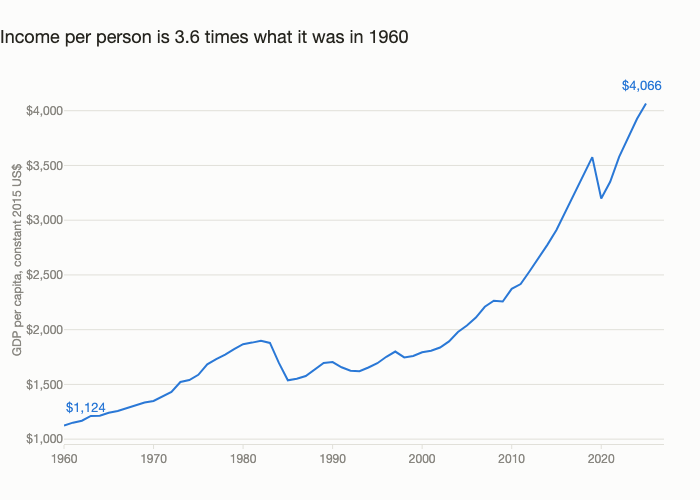

In [2]:
s = df["gdp_per_capita_const"].dropna()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=s.index, y=s.values, mode="lines", line=dict(color=BLUE, width=2),
    name="GDP per capita", hovertemplate="%{x}: $%{y:,.0f}<extra></extra>"))

for yr, dy in [(1960, 22), (2025, -4)]:
    fig.add_annotation(x=yr, y=s[yr], text=f"${s[yr]:,.0f}", showarrow=False,
                       yshift=18, xshift=dy, font=dict(color=BLUE, size=13))

fig.update_layout(
    title="Income per person is 3.6 times what it was in 1960",
    yaxis_title="GDP per capita, constant 2015 US$",
    xaxis_title=None, yaxis_tickprefix="$", yaxis_tickformat=",")
save(fig, "01-gdp-per-capita")
fig.show()

### Observation
Output per person rose from $1,124 in 1960 to $4,066 in 2025, in constant 2015
dollars, so inflation is already stripped out. The rise is not even. The line
climbs slowly to $1,898 in 1982, collapses, and does not clear that 1982 level
again until 2004, a lost twenty-two years.

### Implication
The country your parents worked in was poorer per head, and for a long stretch
it was also stuck. Income per person grew about half between 1960 and 1990;
four fifths of the total dollar gain arrived after 1995. The 3.6x is real, but
it was earned in one working lifetime, not spread over sixty-five years.

### Possible Action
Compare your household against the era your parents actually worked in, not
against 1960. If their peak earning years fell between 1982 and 2004, they
worked through a period when average income went nowhere, which is a fairer
benchmark than the headline 3.6x.

## 2. How steady that growth was

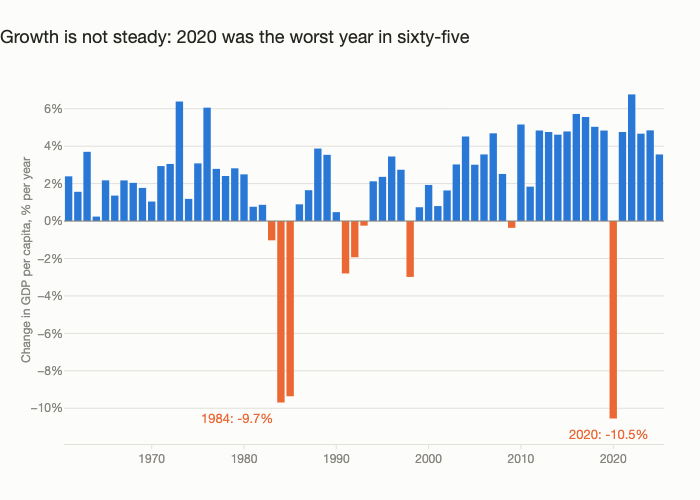

In [3]:
g = df["gdp_growth_pct"].dropna()
colors = [ORANGE if v < 0 else BLUE for v in g.values]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=g.index, y=g.values, marker_color=colors, marker_line_width=0,
    hovertemplate="%{x}: %{y:.2f}%<extra></extra>"))
fig.add_hline(y=0, line_color=MUTED, line_width=1)

for yr, dx in [(1984, -44), (2020, -4)]:
    fig.add_annotation(x=yr, y=g[yr], text=f"{yr}: {g[yr]:.1f}%",
                       showarrow=False, yshift=-16, xshift=dx,
                       font=dict(color=ORANGE, size=13))

fig.update_layout(
    title="Growth is not steady: 2020 was the worst year in sixty-five",
    yaxis_title="Change in GDP per capita, % per year",
    xaxis_title=None, yaxis_ticksuffix="%")
save(fig, "02-gdp-growth")
fig.show()

### Observation
Orange bars are years income per person shrank. The deepest is 2020 at -10.55%.
Next are 1984 at -9.69% and 1985 at -9.37%, back to back, when inflation also
hit 50.3%. Two runs lasted three years each, 1983-1985 and 1991-1993; 1998,
2009 and 2020 were single bad years.

### Implication
The average in chart 1 hides the fact that a Filipino household can lose a
decade of gains in two or three years. Anyone whose plan assumes steady annual
raises is planning against a record that shows a collapse roughly every fifteen
years.

### Possible Action
Size your emergency savings against a two-year shock, not a two-month one. If
you are weighing a job abroad, note that 2020 hit both the local economy and
overseas work at once, so treat a foreign contract as a different income
stream, not a guaranteed hedge.

## 3. Lifespan

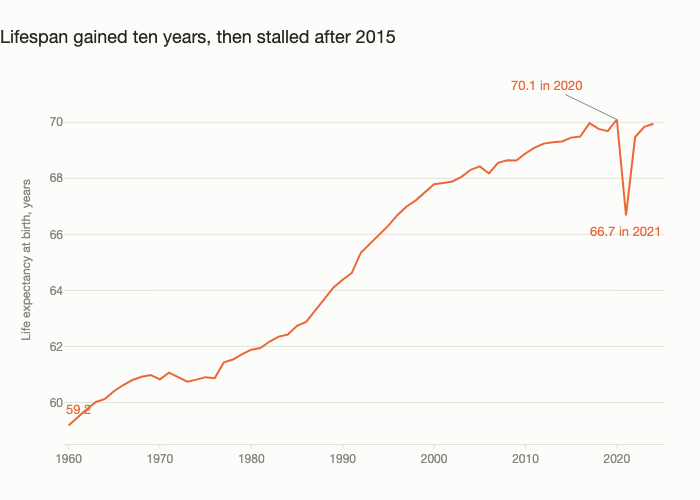

In [4]:
le = df["life_expectancy"].dropna()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=le.index, y=le.values, mode="lines", line=dict(color=ORANGE, width=2),
    hovertemplate="%{x}: %{y:.1f} years<extra></extra>"))

fig.add_annotation(x=2020, y=le[2020], text="70.1 in 2020", showarrow=True,
                   arrowhead=0, arrowwidth=1, arrowcolor=MUTED,
                   ax=-70, ay=-34, font=dict(color=ORANGE, size=13))
fig.add_annotation(x=2021, y=le[2021], text="66.7 in 2021", showarrow=False,
                   yshift=-16, font=dict(color=ORANGE, size=13))
fig.add_annotation(x=1960, y=le[1960], text="59.2", showarrow=False,
                   yshift=16, xshift=10, font=dict(color=ORANGE, size=13))

fig.update_layout(
    title="Lifespan gained ten years, then stalled after 2015",
    yaxis_title="Life expectancy at birth, years", xaxis_title=None)
save(fig, "03-life-expectancy")
fig.show()

### Observation
Life expectancy climbed from 59.2 years in 1960 to 69.95 in 2024, a gain of
10.8 years. Almost all of it came before 2015; the last decade added about half
a year. The peak was 70.1 in 2020, then 2021 fell to 66.68, and 2024 is still
under the 2020 mark. The series ends at 2024 because the 2025 figure is not
published yet.

### Implication
This is the clearest evidence life got better, and it is also where the
improvement stopped. Your generation is gaining lifespan far more slowly than
your parents' generation did, and the COVID loss has not been fully recovered.
Money kept rising after 2015; years of life did not.

### Possible Action
Stop treating extra lifespan as automatic. Spend on the things that produce it
directly, such as PhilHealth cover, blood pressure and blood sugar checks, and
adult vaccination, rather than assuming the trend carries you the way it
carried the generation before.

## 4. Remittances

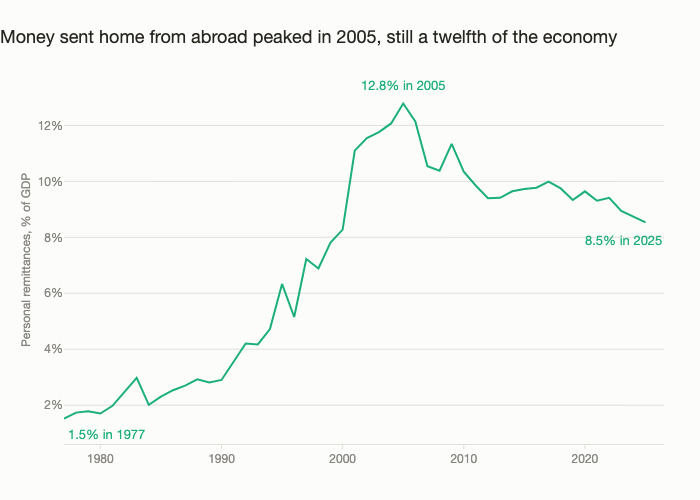

In [5]:
r = df["remittances"].dropna()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=r.index, y=r.values, mode="lines", line=dict(color=AQUA, width=2),
    hovertemplate="%{x}: %{y:.1f}% of GDP<extra></extra>"))

fig.add_annotation(x=1977, y=r[1977], text="1.5% in 1977", showarrow=False,
                   yshift=-16, xshift=42, font=dict(color=AQUA, size=13))
fig.add_annotation(x=2005, y=r[2005], text="12.8% in 2005", showarrow=False,
                   yshift=18, font=dict(color=AQUA, size=13))
fig.add_annotation(x=2025, y=r[2025], text="8.5% in 2025", showarrow=False,
                   yshift=-18, xshift=-22, font=dict(color=AQUA, size=13))

fig.update_layout(
    title="Money sent home from abroad peaked in 2005, still a twelfth of the economy",
    yaxis_title="Personal remittances, % of GDP",
    xaxis_title=None, yaxis_ticksuffix="%")
save(fig, "04-remittances")
fig.show()

### Observation
Remittances rose from 1.5% of GDP in 1977 to 8.5% in 2025. The steep climb runs
through the 1990s, the same stretch when income per person at home stayed
below its 1982 level. The share peaked at 12.8% in 2005 and has drifted down
for twenty years since.

### Implication
Remittances grew in the same years as the gain in chart 1. This data cannot say
how much of the gain they explain. Working abroad is not a fringe choice here;
it is a structural feature of the economy large enough to move the national
accounts. It also means the household benefit is real and measurable, not just
anecdote.

### Possible Action
If you are deciding whether to work abroad, price the whole package: the wage
gap, the recruitment and travel cost, the years apart, and what happens if the
posting ends early. The twenty-year slide since 2005 says overseas money is
losing ground against a home economy that is now growing, so run the numbers on
today's gap, not on the one a relative got in 2005.

## 5. Who ended up holding it

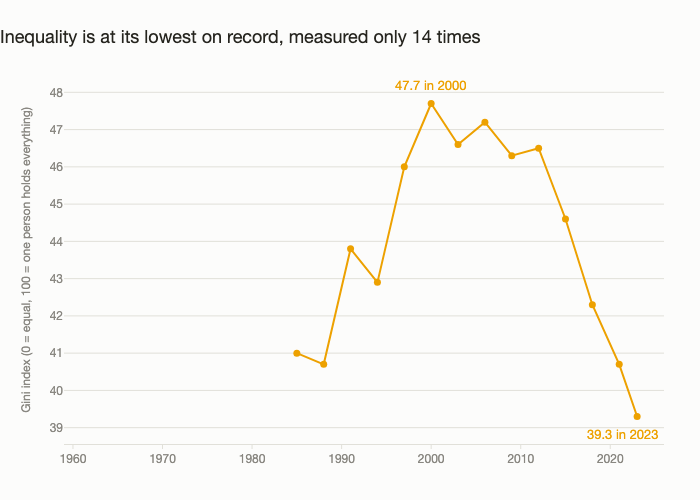

In [6]:
gi = df["gini"].dropna()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=gi.index, y=gi.values, mode="lines+markers",
    line=dict(color=YELLOW, width=2), marker=dict(color=YELLOW, size=7),
    hovertemplate="%{x}: %{y:.1f}<extra></extra>"))

fig.add_annotation(x=2000, y=gi[2000], text="47.7 in 2000", showarrow=False,
                   yshift=18, font=dict(color=YELLOW, size=13))
fig.add_annotation(x=2023, y=gi[2023], text="39.3 in 2023", showarrow=False,
                   yshift=-18, xshift=-14, font=dict(color=YELLOW, size=13))

fig.update_layout(
    title="Inequality is at its lowest on record, measured only 14 times",
    yaxis_title="Gini index (0 = equal, 100 = one person holds everything)",
    xaxis_title=None, xaxis_range=[1959, 2026])
save(fig, "05-gini")
fig.show()

### Observation
The Gini index reads 41.0 in 1985, 47.7 in 2000, and 39.3 in 2023. The survey
basis changes in 2000: readings up to 1997 measure consumption and readings from
2000 measure income, so the two halves are not directly comparable. On the
income basis alone, Gini fell from 47.7 to 39.3. There are only 14 points across 38
years because this comes from household surveys run every few years, and there
is no Philippine figure at all before 1985. The wide spacing between markers is
missing measurement, not a flat trend.

### Implication
Since 2000 the gains have spread out rather than concentrating further, which
supports reading the income rise in chart 1 as something the average household
saw, not only the top. But 39.3 is still high, and 14 survey points cannot tell
you what happened in any particular year, including the one you are living in.

### Possible Action
Treat "the economy grew" as a claim about your own household only when your own
numbers agree. Track your real spending power year to year, and use the
`peso100_in_2024_pesos` column when someone tells you prices were better before:
₱100 in 1960 was worth about ₱14,142 in 2024 money, so old prices mean nothing
until they are converted.

## Inference: what this does and doesn't show

**Yes, but less than the money suggests, and it has largely stopped.**

Income per person is 3.6 times its 1960 level and Filipinos live 10.8 years
longer. Both are real gains, and neither is evenly spread across the 65 years:
income per person needed until 2004 to beat its 1982 level, and the lifespan
gain is almost entirely pre-2015. Since 2015 the average Filipino has gained
about half a year of life, still sits below the 2020 lifespan peak, and watched
primary school enrollment slip from 99.4% in 2017 to 94.0% in 2024. Inequality
fell on a consistent basis: from 47.7 in 2000 to 39.3 in 2023 on the income
measure the World Bank has used since 2000.

So a person born now is better off than one born in 1960 on the measures that
reach back to 1960: income per person and lifespan. The other indicators start
later (school enrollment 1971, remittances 1977, household consumption 1981,
Gini 1985, unemployment 1991, health spending 2000), so they cannot answer the
1960 question. School enrollment, the oldest of them, sits lower in 2024
(94.0%) than in 1971 (99.5%). A person comparing today with their parents'
working years in the 1990s and 2000s has a much weaker case, because that is
where most of the improvement already happened.

Three limits on this answer. Every income figure is a national average and says
nothing about your household. The 2.2% reported unemployment is an ILO-modelled
estimate that leaves out underemployment and informal work, so it is not
evidence of a healthy job market and is not charted here. And remittances grew
alongside the gains, reaching 8.5% of GDP in 2025; this data cannot say how
much of the improvement they explain, and the cost of families living apart
shows up in no indicator on this page.